In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier

import pickle as pkl

import warnings
warnings.filterwarnings("ignore")

In [4]:
# =========================
# Load Data
# =========================
df = pd.read_csv("clean_data.csv")

diabetes
0    87664
1     8482
Name: count, dtype: int64


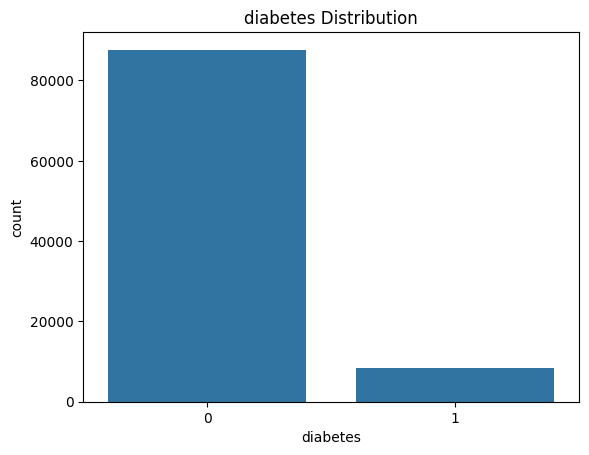

In [5]:
# Countplot to check the data balanced or not
print(df["diabetes"].value_counts())

sns.countplot(x=df["diabetes"])
plt.title("diabetes Distribution")
plt.show()

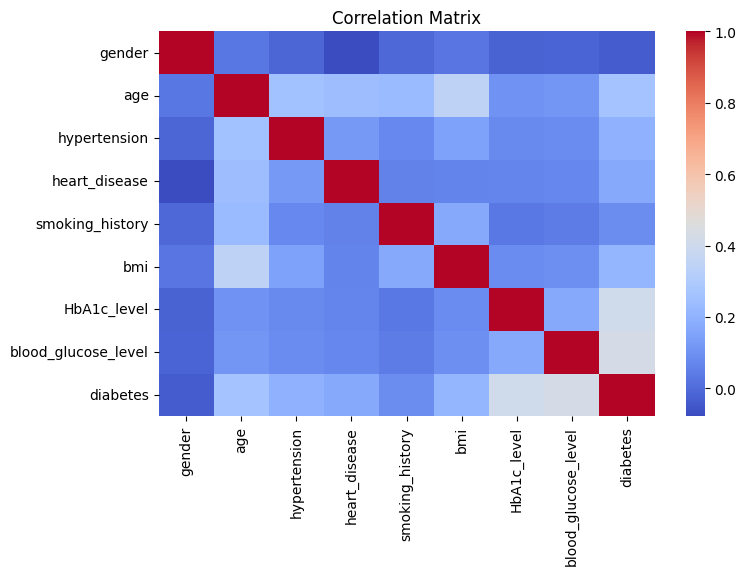

In [6]:
# To find correlations between all features
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
# Independent variables (features)
X = df.drop("diabetes", axis=1)

# Dependent variable (target)
y = df["diabetes"]

In [10]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [11]:
categorical_features = [
    'gender',
    'hypertension',
    'heart_disease',
    'smoking_history'
]
numerical_features = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

In [12]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

In [14]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [15]:
param_grids = {

    "Logistic Regression": {
        "model__C": np.logspace(-3, 3, 10)
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10]
    },

    "Decision Tree": {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
}

In [16]:
# Training Loop 

best_models = {}
best_accuracy = 0
best_model = None
best_model_name = ""

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)    #=>  model = LogisticRegression(max_iter=1000)
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=20,
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    predictions = search.predict(X_test)

    print(f"\n{name} Accuracy:", accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))

    best_models[name] = search.best_estimator_
    
    y_pred = search.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = search.best_estimator_
        best_model_name = name


Training Decision Tree...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Decision Tree Accuracy: 0.970566822672907
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       1.00      0.67      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [17]:
# Export the best model based on Accuracy

import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print(f"\n✅ Best Model Saved: {best_model_name}")
print(f"✅ Accuracy: {best_accuracy}")


✅ Best Model Saved: Decision Tree
✅ Accuracy: 0.970566822672907
